# Notebook 01: Exploratory Data Analysis (EDA)

## Objective

This notebook explores the IEEE-CIS Fraud Detection dataset to understand its structure, data quality, class distribution and feature characteristics. The findings from this analysis will inform the preprocessing strategy and model development stages of the TrustLens project.

In [ ]:
# Cell 1 → Import libraries & load datasets

from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path("../data/raw")

train_transaction = pd.read_csv(DATA_DIR / "train_transaction.csv")
train_identity = pd.read_csv(DATA_DIR / "train_identity.csv")

print("Transaction shape:", train_transaction.shape)
print("Identity shape:", train_identity.shape)

df = train_transaction.merge(train_identity, on="TransactionID", how="left")

print("Merged shape:", df.shape)
df.head()

Transaction shape: (590540, 394)
Identity shape: (144233, 41)
Merged shape: (590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [ ]:
# Cell 2 → Fraud class distribution

target_col = "isFraud"

fraud_counts = df[target_col].value_counts()
fraud_percentage = df[target_col].value_counts(normalize=True) * 100

print("Fraud counts:")
print(fraud_counts)

print("\nFraud percentage:")
print(fraud_percentage)

Fraud counts:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud percentage:
isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


In [ ]:
# Cell 3 → Missing values

missing_values = df.isnull().mean().sort_values(ascending=False) * 100

missing_summary = missing_values.reset_index()
missing_summary.columns = ["feature", "missing_percentage"]

missing_summary.head(20)

,feature,missing_percentage
0,id_24,99.196159
1,id_25,99.130965
2,id_07,99.127070
3,id_08,99.127070
4,id_21,99.126393
5,id_26,99.125715
6,id_27,99.124699
7,id_23,99.124699
8,id_22,99.124699
9,dist2,93.628374


In [ ]:
# Cell 4 → Numeric vs categorical features

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Number of numeric columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))

print("\nSample categorical columns:")
print(categorical_cols[:20])

Number of numeric columns: 403
Number of categorical columns: 31

Sample categorical columns:
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28']


Matplotlib is building the font cache; this may take a moment.


<Axes: title={'center': 'Fraud vs Non-Fraud Transactions'}, xlabel='isFraud'>

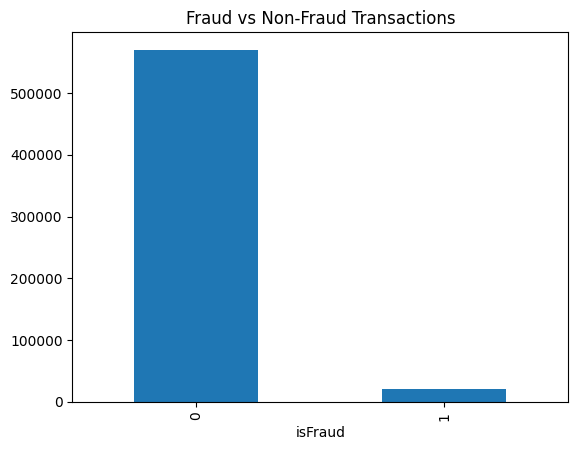

In [ ]:
# Cell 5 → Fraud distribution chart

df[target_col].value_counts().plot(
    kind="bar",
    title="Fraud vs Non-Fraud Transactions"
)

In [8]:
# Cell 6 → Missing value groups

missing_percentage = df.isnull().mean() * 100

missing_groups = {
    "0% missing": (missing_percentage == 0).sum(),
    "0-25% missing": ((missing_percentage > 0) & (missing_percentage <= 25)).sum(),
    "25-50% missing": ((missing_percentage > 25) & (missing_percentage <= 50)).sum(),
    "50-75% missing": ((missing_percentage > 50) & (missing_percentage <= 75)).sum(),
    "75-90% missing": ((missing_percentage > 75) & (missing_percentage <= 90)).sum(),
    "90%+ missing": (missing_percentage > 90).sum(),
}

print(missing_groups)

{'0% missing': np.int64(20), '0-25% missing': np.int64(162), '25-50% missing': np.int64(38), '50-75% missing': np.int64(6), '75-90% missing': np.int64(196), '90%+ missing': np.int64(12)}


In [9]:
# Cell 7 → Transaction amount statistics by class

df.groupby("isFraud")["TransactionAmt"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


In [ ]:
# Cell 8 → Fraud rate by ProductCD
product_fraud = df.groupby("ProductCD")["isFraud"].agg(["count", "sum", "mean"])
product_fraud["fraud_rate_percentage"] = product_fraud["mean"] * 100
product_fraud.sort_values("fraud_rate_percentage", ascending=False)

,count,sum,mean,fraud_rate_percentage
ProductCD,,,,
C,68519,8008,0.116873,11.687269
S,11628,686,0.058996,5.899553
H,33024,1574,0.047662,4.766231
R,37699,1426,0.037826,3.782594
W,439670,8969,0.020399,2.039939


In [11]:
# Cell 9 → Fraud rate by card type

card4_fraud = df.groupby("card4")["isFraud"].agg(["count", "sum", "mean"])
card4_fraud["fraud_rate_percentage"] = card4_fraud["mean"] * 100
card4_fraud.sort_values("fraud_rate_percentage", ascending=False)

,count,sum,mean,fraud_rate_percentage
card4,,,,
discover,6651,514,0.077282,7.728161
visa,384767,13373,0.034756,3.475610
mastercard,189217,6496,0.034331,3.433095
american express,8328,239,0.028698,2.869837


In [12]:
# Cell 10 → Fraud rate by card6

card6_fraud = df.groupby("card6")["isFraud"].agg(["count", "sum", "mean"])
card6_fraud["fraud_rate_percentage"] = card6_fraud["mean"] * 100
card6_fraud.sort_values("fraud_rate_percentage", ascending=False)

,count,sum,mean,fraud_rate_percentage
card6,,,,
credit,148986,9950,0.066785,6.678480
debit,439938,10674,0.024263,2.426251
charge card,15,0,0.000000,0.000000
debit or credit,30,0,0.000000,0.000000


In [ ]:
# Cell 11 → Fraud rate by DeviceType

device_fraud = df.groupby("DeviceType")["isFraud"].agg(["count", "sum", "mean"])
device_fraud["fraud_rate_percentage"] = device_fraud["mean"] * 100
device_fraud.sort_values("fraud_rate_percentage", ascending=False)

,count,sum,mean,fraud_rate_percentage
DeviceType,,,,
mobile,55645,5657,0.101662,10.166232
desktop,85165,5554,0.065215,6.521458


In [15]:
# Cell 12 → Top 20 DeviceInfo values

device_info_summary = df["DeviceInfo"].value_counts(dropna=False).head(20)
device_info_summary

DeviceInfo
NaN                            471874
Windows                         47722
iOS Device                      19782
MacOS                           12573
Trident/7.0                      7440
rv:11.0                          1901
rv:57.0                           962
SM-J700M Build/MMB29K             549
SM-G610M Build/MMB29K             461
SM-G531H Build/LMY48B             410
rv:59.0                           362
SM-G935F Build/NRD90M             334
SM-G955U Build/NRD90M             328
SM-G532M Build/MMB29T             316
ALE-L23 Build/HuaweiALE-L23       312
SM-G950U Build/NRD90M             290
SM-G930V Build/NRD90M             274
rv:58.0                           269
rv:52.0                           256
SAMSUNG                           235
Name: count, dtype: int64

In [16]:
# Cell 13 → Fraud rate by email domain

email_fraud = df.groupby("P_emaildomain")["isFraud"].agg(["count", "sum", "mean"])
email_fraud["fraud_rate_percentage"] = email_fraud["mean"] * 100
email_fraud.sort_values("fraud_rate_percentage", ascending=False).head(20)

,count,sum,mean,fraud_rate_percentage
P_emaildomain,,,,
protonmail.com,76,31,0.407895,40.789474
mail.com,559,106,0.189624,18.962433
outlook.es,438,57,0.130137,13.013699
aim.com,315,40,0.126984,12.698413
outlook.com,5096,482,0.094584,9.458399
hotmail.es,305,20,0.065574,6.557377
live.com.mx,749,41,0.054740,5.473965
hotmail.com,45250,2396,0.052950,5.295028
gmail.com,228355,9943,0.043542,4.354185


In [17]:
# Cell 14 → Top numeric correlations with fraud target

numeric_df = df.select_dtypes(include=["int64", "float64"])

correlations = numeric_df.corr(numeric_only=True)["isFraud"].drop("isFraud").sort_values(key=abs, ascending=False)

correlations.head(20)

V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
V158    0.278066
V156    0.275952
V149    0.273282
V228    0.268861
V44     0.260376
V86     0.251828
V87     0.251737
V170    0.249794
V147    0.242894
V52     0.239469
Name: isFraud, dtype: float64

In [18]:
# Save useful EDA summary tables for dissertation evidence

from pathlib import Path

RESULTS_DIR = Path("../results/metrics")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

missing_summary.to_csv(RESULTS_DIR / "missing_values_summary.csv", index=False)
product_fraud.to_csv(RESULTS_DIR / "fraud_rate_by_product.csv")
card4_fraud.to_csv(RESULTS_DIR / "fraud_rate_by_card4.csv")
card6_fraud.to_csv(RESULTS_DIR / "fraud_rate_by_card6.csv")
device_fraud.to_csv(RESULTS_DIR / "fraud_rate_by_device_type.csv")
email_fraud.to_csv(RESULTS_DIR / "fraud_rate_by_email_domain.csv")
correlations.to_csv(RESULTS_DIR / "numeric_correlations_with_fraud.csv")

print("EDA summary files saved successfully.")

EDA summary files saved successfully.
